In [1]:
import torch
import matplotlib.pyplot as plt

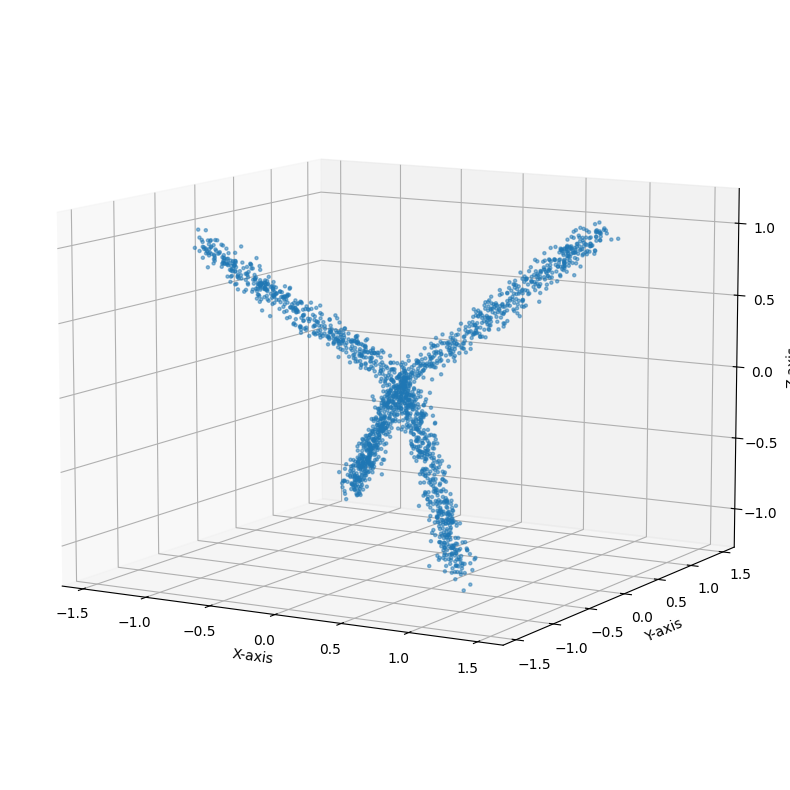

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
sigma = 0.05
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += sigma * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.show()

In [3]:
N = data.shape[0]
X = data.T  # shape (d, N)
r = 4  # number of clusters/end-members

idx = torch.randint(0, N, (1,))
V = X[:, idx]
for _ in range(1, r):
    dist = torch.cdist(X.T, V.T)
    min_dist, _ = dist.min(dim=1)
    next_idx = torch.argmax(min_dist)
    V = torch.cat([V, X[:, next_idx:next_idx+1]], dim=1)

# initialize F and G based on V
XTV = X.T @ V
F = torch.softmax(XTV, dim=0)
G = torch.softmax(XTV.T, dim=0)

print(F.shape)
print(G.shape)

torch.Size([2000, 4])
torch.Size([4, 2000])


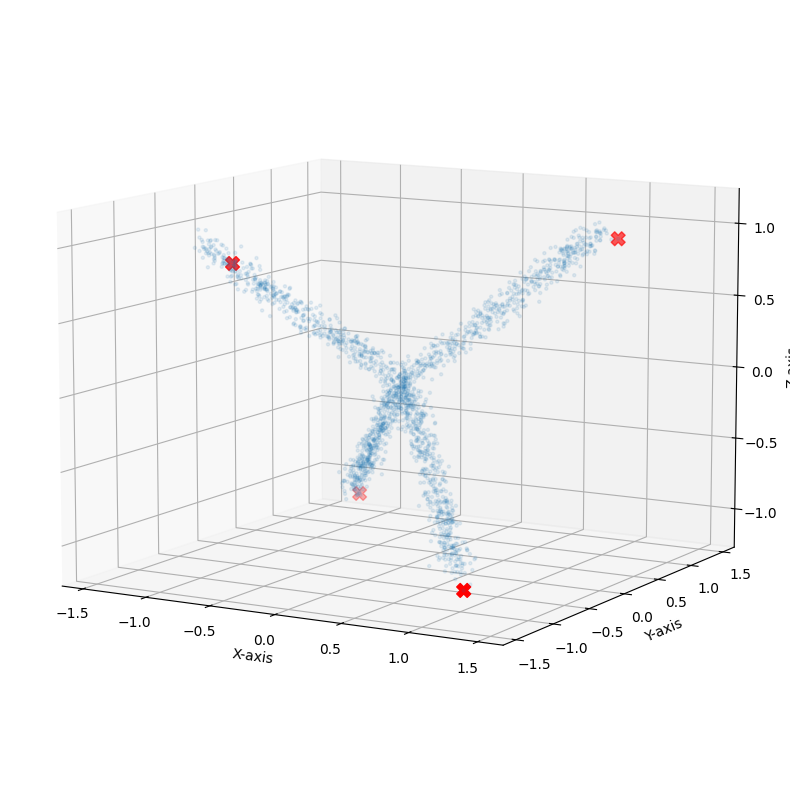

In [4]:
# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.1)
ax.scatter(V[0, :], V[1, :], V[2, :], s=100, c='red', marker='X', label='End Members')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.show()

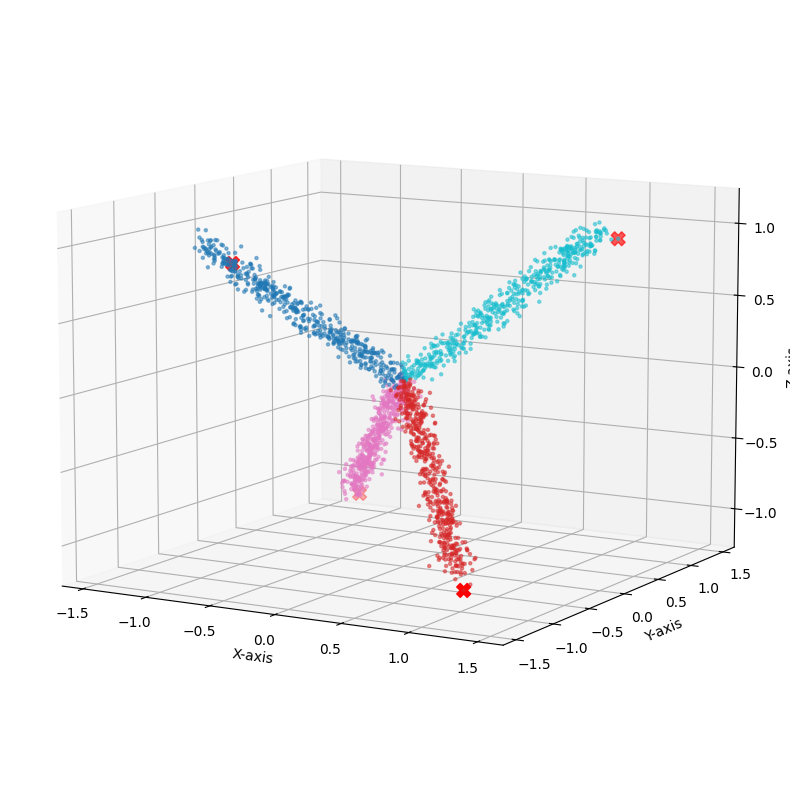

In [5]:
# plot class assignments in 3D
labels = torch.argmax(G, dim=0)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, c=labels.cpu(), cmap='tab10', alpha=0.5)  
ax.scatter(V[0, :], V[1, :], V[2, :], s=100, c='red', marker='X', label='End Members')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.show()